# EDA — Clinical Tabular ML: Hospital Readmission at 30 Days
**Dataset:** Diabetes 130-US Hospitals (UCI) | 101.766 encounters | 55 variables  
**Objetivo:** Conocer la estructura real de los datos antes de cualquier decisión de procesamiento.  
**Nota metodológica:** En este dataset, los valores faltantes están codificados como `'?'`, no como `NaN`. 
Toda auditoría de missingness debe contemplar esto explícitamente.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from pathlib import Path

# Display settings
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

print("Libraries loaded ")

Libraries loaded 


In [2]:

DATA_PATH = Path('../data/raw/diabetic_data.csv')
df = pd.read_csv(DATA_PATH)
# Initial data exploration
print(f"Shape: {df.shape}")
print(f"Encounters: {df.shape[0]:,}")
print(f"Variables: {df.shape[1]}")

Shape: (101766, 50)
Encounters: 101,766
Variables: 50


#esperabamos 55 variables

In [3]:
# Auditoría de columnas — ¿qué tenemos realmente?
print("=== COLUMNAS DEL DATASET ===\n")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2}. {col}")

=== COLUMNAS DEL DATASET ===

 1. encounter_id
 2. patient_nbr
 3. race
 4. gender
 5. age
 6. weight
 7. admission_type_id
 8. discharge_disposition_id
 9. admission_source_id
10. time_in_hospital
11. payer_code
12. medical_specialty
13. num_lab_procedures
14. num_procedures
15. num_medications
16. number_outpatient
17. number_emergency
18. number_inpatient
19. diag_1
20. diag_2
21. diag_3
22. number_diagnoses
23. max_glu_serum
24. A1Cresult
25. metformin
26. repaglinide
27. nateglinide
28. chlorpropamide
29. glimepiride
30. acetohexamide
31. glipizide
32. glyburide
33. tolbutamide
34. pioglitazone
35. rosiglitazone
36. acarbose
37. miglitol
38. troglitazone
39. tolazamide
40. examide
41. citoglipton
42. insulin
43. glyburide-metformin
44. glipizide-metformin
45. glimepiride-pioglitazone
46. metformin-rosiglitazone
47. metformin-pioglitazone
48. change
49. diabetesMed
50. readmitted


## Hallazgo 1 — Dimensiones reales
Shape confirmado: 101.766 encuentros × 50 variables.
La ficha técnica del proyecto citaba 55 variables — discrepancia con el dataset real de UCI.
Las 50 columnas presentes cubren todas las categorías relevantes:
IDs, demográficas, clínicas, medicación (24 fármacos), diagnósticos y target.
No hay columnas faltantes respecto a la versión descargable actual.

In [4]:
# Tipos de datos
print("=== DTYPES ===")
print(df.dtypes.value_counts())
print("\n")
print(df.dtypes)

=== DTYPES ===
object    37
int64     13
Name: count, dtype: int64


encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age                         object
weight                      object
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
payer_code                  object
medical_specialty           object
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum               object
A1Cresult                   object
metformin                   object
repaglinide                 object
nateglinide          

In [5]:
# Primeras filas — ojo visual a los '?'
df.head(10)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO
5,35754,82637451,Caucasian,Male,[50-60),?,2,1,2,3,?,?,31,6,16,0,0,0,414,411,250,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Yes,>30
6,55842,84259809,Caucasian,Male,[60-70),?,3,1,2,4,?,?,70,1,21,0,0,0,414,411,V45,7,NaN,NaN,Steady,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO
7,63768,114882984,Caucasian,Male,[70-80),?,1,1,7,5,?,?,73,0,12,0,0,0,428,492,250,8,NaN,NaN,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,>30
8,12522,48330783,Caucasian,Female,[80-90),?,2,1,4,13,?,?,68,2,28,0,0,0,398,427,38,8,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO
9,15738,63555939,Caucasian,Female,[90-100),?,3,3,4,12,?,InternalMedicine,33,3,18,0,0,0,434,198,486,8,NaN,NaN,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [ ]:
# === AUDITORÍA DE MISSINGNESS ===
# Este dataset usa '?' como código de faltante en columnas object, y NaN en columnas numéricas. 

print("=== NaN REALES (detectado automáticamente) ===")
nan_counts = df.isnull().sum()
nan_counts = nan_counts[nan_counts > 0].sort_values(ascending=False)
print(nan_counts)
print(f"\nTotal columnas con NaN: {len(nan_counts)}")

print("\n=== '?' SILENCIOSOS (codificados como string) ===")
question_counts = {}
for col in df.select_dtypes(include='object').columns:
    count = (df[col] == '?').sum()
    if count > 0:
        question_counts[col] = count

q_series = pd.Series(question_counts).sort_values(ascending=False)
q_pct = (q_series / len(df) * 100).round(1)
audit = pd.DataFrame({'count': q_series, 'pct_%': q_pct})
print(audit)

=== NaN REALES (detectado automáticamente) ===
max_glu_serum    96420
A1Cresult        84748
dtype: int64

Total columnas con NaN: 2

=== '?' SILENCIOSOS (codificados como string) ===
                   count  pct_%
weight             98569 96.900
medical_specialty  49949 49.100
payer_code         40256 39.600
race                2273  2.200
diag_3              1423  1.400
diag_2               358  0.400
diag_1                21  0.000


# weight con 96.9% faltante es prácticamente inutilizable como feature predictivo — se elimina. medical_specialty y payer_code con ~40-50% requieren decisión con criterio. race con 2.2% es manejable con categoría 'Unknown'. Los diagnósticos con menos de 2% son casos puntuales.

In [ ]:
# === MAPA UNIFICADO DE MISSINGNESS === Combinamos NaN reales + '?' para tener visión completa

missing_unified = {}

for col in df.columns:
    nan_count = df[col].isnull().sum()
    q_count = (df[col] == '?').sum() if df[col].dtype == 'object' else 0
    total = nan_count + q_count
    if total > 0:
        missing_unified[col] = {
            'nan_real': nan_count,
            'question_mark': q_count,
            'total_missing': total,
            'pct_missing': round(total / len(df) * 100, 1)
        }

missing_df = pd.DataFrame(missing_unified).T.sort_values('pct_missing', ascending=False)
missing_df = missing_df.astype({'nan_real': int, 'question_mark': int, 'total_missing': int})
print(missing_df)

                   nan_real  question_mark  total_missing  pct_missing
weight                    0          98569          98569       96.900
max_glu_serum         96420              0          96420       94.700
A1Cresult             84748              0          84748       83.300
medical_specialty         0          49949          49949       49.100
payer_code                0          40256          40256       39.600
race                      0           2273           2273        2.200
diag_3                    0           1423           1423        1.400
diag_2                    0            358            358        0.400
diag_1                    0             21             21        0.000


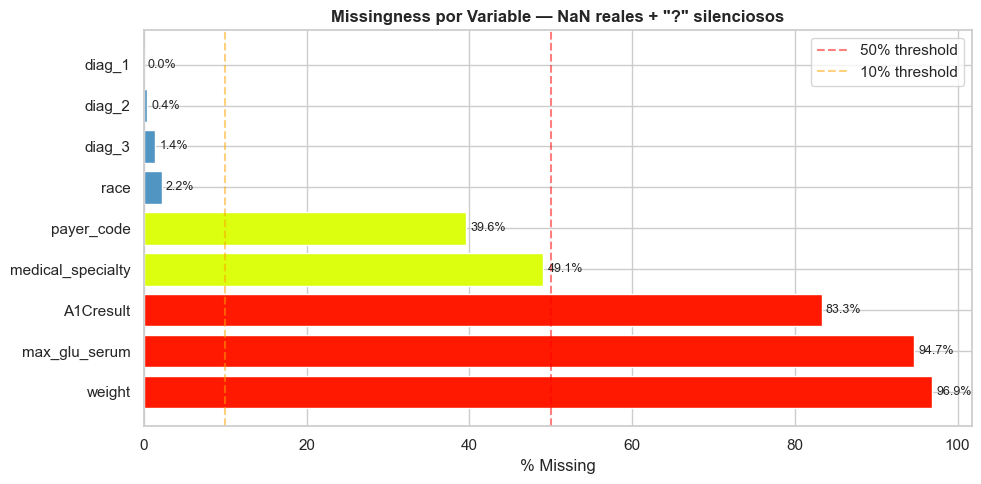

In [8]:
# === VISUALIZACIÓN ===
fig, ax = plt.subplots(figsize=(10, 5))

colors = ["#ff1900" if p > 50 else "#dbff0e" if p > 10 else "#5195c3" 
          for p in missing_df['pct_missing']]

bars = ax.barh(missing_df.index, missing_df['pct_missing'], color=colors)
ax.axvline(x=50, color='red', linestyle='--', alpha=0.5, label='50% threshold')
ax.axvline(x=10, color='orange', linestyle='--', alpha=0.5, label='10% threshold')

for bar, pct in zip(bars, missing_df['pct_missing']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{pct}%', va='center', fontsize=9)

ax.set_xlabel('% Missing')
ax.set_title('Missingness por Variable — NaN reales + "?" silenciosos', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/missingness_map.png', dpi=150)
plt.show()

##  Hallazgo 2 — Mapa de Missingness

**Dos sistemas de missingness coexisten en este dataset:**
- `NaN` reales: `max_glu_serum` (94.7%) y `A1Cresult` (83.3%) — probablemente preprocesadas en esta versión
- `'?'` como string: resto de variables con faltantes

**Decisiones anticipadas por variable:**

| Variable | % Missing | Decisión |
|---|---|---|
| `weight` | 96.9% |  Eliminar — inutilizable como feature |
| `max_glu_serum` | 94.7% |  Conservar valor cuando presente + flag `fue_medido_glucemia` |
| `A1Cresult` | 83.3% |  Conservar valor cuando presente + flag `fue_medido_A1C` |
| `medical_specialty` | 49.1% |  Evaluar — posible categoría 'Unknown', señal clínica baja |
| `payer_code` | 39.6% |  Candidato a eliminar — variable administrativa, no clínica |
| `race` | 2.2% |  Categoría explícita 'Unknown' — no imputar con moda |
| `diag_1/2/3` | <2% |  Tratar puntualmente — agrupar ICD-9 en etapa de features |

**Nota:** El proyecto original anticipaba ~75% missing en `max_glu_serum` y `A1Cresult`.
Los valores reales son mayores — esto refuerza la estrategia de missingness informativo.

In [9]:
# === DISTRIBUCIÓN DEL TARGET ===
target_counts = df['readmitted'].value_counts()
target_pct = df['readmitted'].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    'count': target_counts,
    'pct_%': target_pct.round(1)
})
print(target_summary)
print(f"\nClass ratio (NO/<30): {target_counts['NO'] / target_counts['<30']:.1f}x")

            count  pct_%
readmitted              
NO          54864 53.900
>30         35545 34.900
<30         11357 11.200

Class ratio (NO/<30): 4.8x


In [10]:
# Recodificación binaria — decisión de diseño del proyecto
df['readmitted_binary'] = (df['readmitted'] == '<30').astype(int)

print("=== TARGET BINARIO ===")
binary_counts = df['readmitted_binary'].value_counts()
print(f"Clase 0 (no readmitido en <30d): {binary_counts[0]:,} ({binary_counts[0]/len(df)*100:.1f}%)")
print(f"Clase 1 (readmitido <30d):       {binary_counts[1]:,} ({binary_counts[1]/len(df)*100:.1f}%)")
print(f"\nScale_pos_weight para XGBoost: {binary_counts[0]/binary_counts[1]:.2f}")

=== TARGET BINARIO ===
Clase 0 (no readmitido en <30d): 90,409 (88.8%)
Clase 1 (readmitido <30d):       11,357 (11.2%)

Scale_pos_weight para XGBoost: 7.96


##  Hallazgo 3 — Distribución del Target

**Distribución original (3 clases):**
- NO readmitido: 53.9%
- Readmitido >30 días: 34.9%  
- Readmitido <30 días: 11.2% ← clase de interés

**Recodificación binaria aplicada:**
- Clase 0 (negativo): NO + >30 = 88.8%
- Clase 1 (positivo): <30 = 11.2%

**Implicaciones metodológicas:**
- Accuracy es una métrica irrelevante — un modelo que predice siempre 0 tiene 88.8% de accuracy
- Métricas relevantes: PR-AUC, Recall clase positiva, F2-score
- scale_pos_weight XGBoost = 7.96 (calculado en este paso, no asumido)
- Threshold por defecto 0.5 no es óptimo — requiere tuning con curva PR

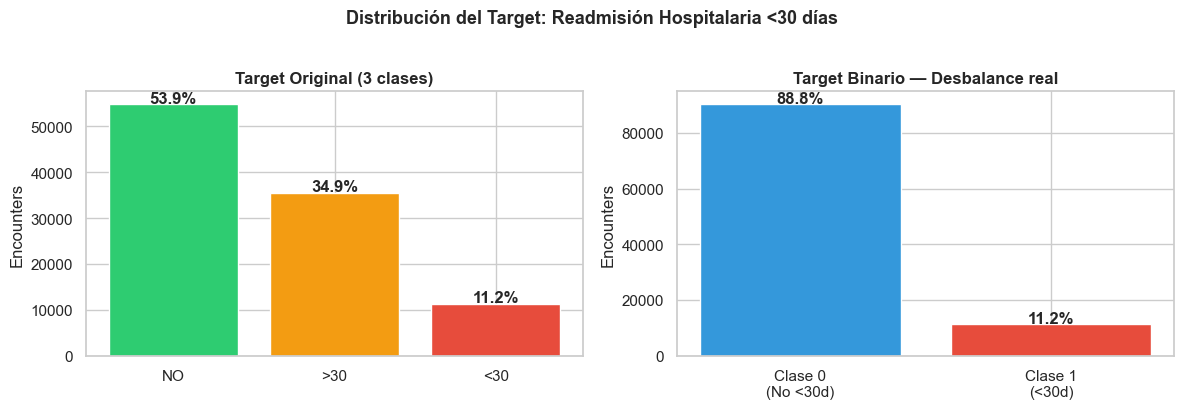

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1 — distribución original
colors_orig = ['#2ecc71', '#f39c12', '#e74c3c']
axes[0].bar(target_counts.index, target_counts.values, color=colors_orig, edgecolor='white')
axes[0].set_title('Target Original (3 clases)', fontweight='bold')
axes[0].set_ylabel('Encounters')
for i, (val, pct) in enumerate(zip(target_counts.values, target_pct.values)):
    axes[0].text(i, val + 300, f'{pct:.1f}%', ha='center', fontweight='bold')

# Plot 2 — target binario
binary_labels = ['Clase 0\n(No <30d)', 'Clase 1\n(<30d)']
binary_vals = [binary_counts[0], binary_counts[1]]
colors_bin = ['#3498db', '#e74c3c']
axes[1].bar(binary_labels, binary_vals, color=colors_bin, edgecolor='white')
axes[1].set_title('Target Binario — Desbalance real', fontweight='bold')
axes[1].set_ylabel('Encounters')
for i, val in enumerate(binary_vals):
    axes[1].text(i, val + 300, f'{val/len(df)*100:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Distribución del Target: Readmisión Hospitalaria <30 días', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/target_distribution.png', dpi=150)
plt.show()

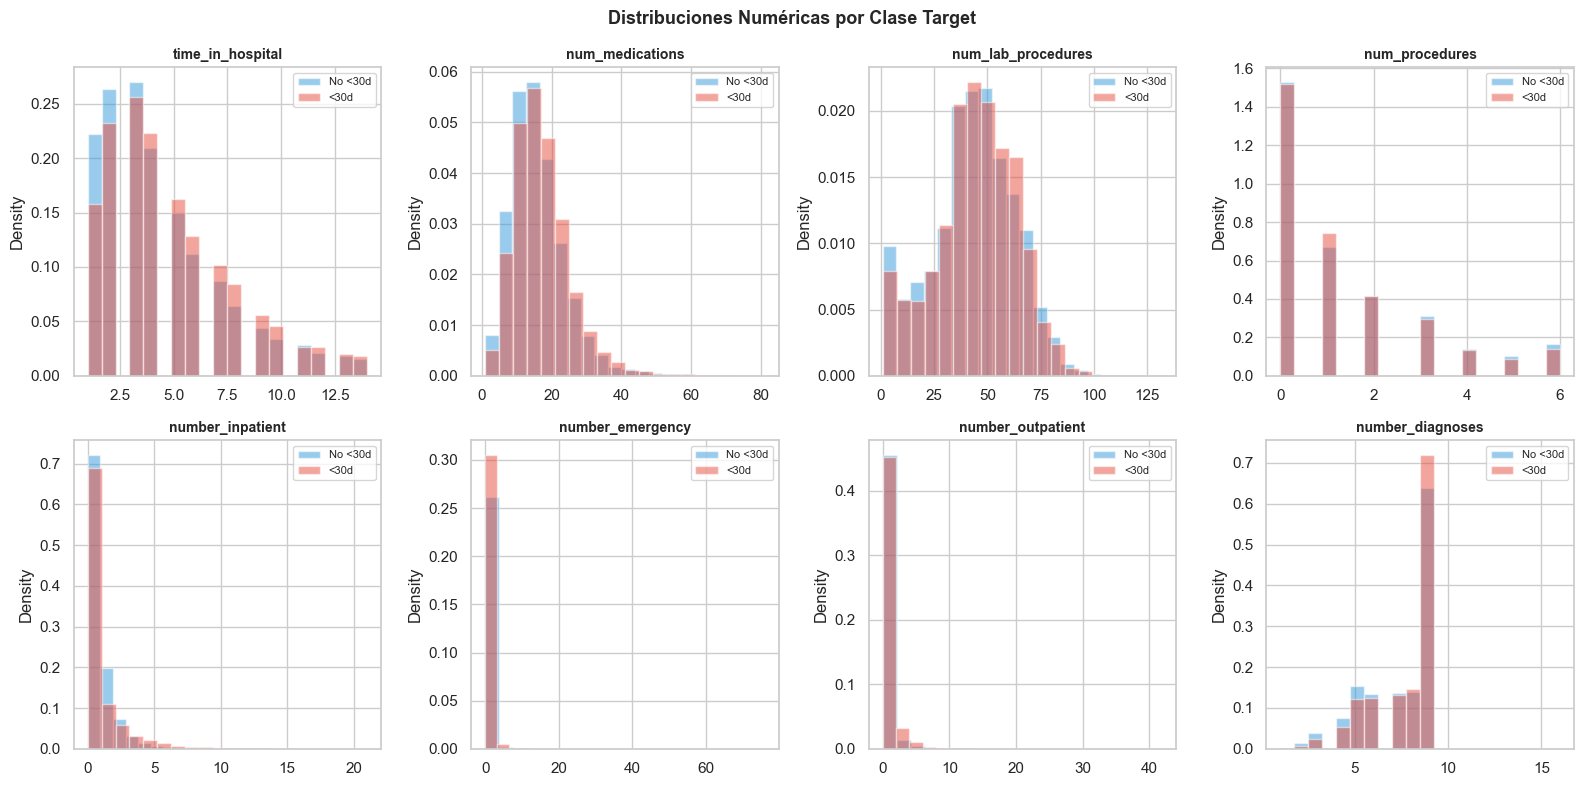

In [12]:
# === DISTRIBUCIONES NUMÉRICAS vs TARGET ===
numeric_vars = [
    'time_in_hospital', 
    'num_medications', 
    'num_lab_procedures',
    'num_procedures',
    'number_inpatient',
    'number_emergency',
    'number_outpatient',
    'number_diagnoses'
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, var in enumerate(numeric_vars):
    class0 = df[df['readmitted_binary'] == 0][var]
    class1 = df[df['readmitted_binary'] == 1][var]
    
    axes[i].hist(class0, bins=20, alpha=0.5, color='#3498db', label='No <30d', density=True)
    axes[i].hist(class1, bins=20, alpha=0.5, color='#e74c3c', label='<30d', density=True)
    axes[i].set_title(var, fontweight='bold', fontsize=10)
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribuciones Numéricas por Clase Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/numeric_distributions.png', dpi=150)
plt.show()

In [13]:
# Estadísticas comparativas — mediana por clase
print("=== MEDIANAS POR CLASE TARGET ===\n")
stats = df.groupby('readmitted_binary')[numeric_vars].median()
stats.index = ['Clase 0 (No <30d)', 'Clase 1 (<30d)']
print(stats.T.to_string())

=== MEDIANAS POR CLASE TARGET ===

                    Clase 0 (No <30d)  Clase 1 (<30d)
time_in_hospital                4.000           4.000
num_medications                15.000          16.000
num_lab_procedures             44.000          45.000
num_procedures                  1.000           1.000
number_inpatient                0.000           0.000
number_emergency                0.000           0.000
number_outpatient               0.000           0.000
number_diagnoses                8.000           9.000


In [14]:
# === ANÁLISIS DE COLAS — donde vive la señal real ===
print("=== MEDIAS Y PERCENTIL 75 POR CLASE ===\n")
print(f"{'Variable':<25} {'mean0':>7} {'mean1':>7} {'Δmean%':>8}  {'p75_0':>6} {'p75_1':>6}")
print("-" * 65)

for var in numeric_vars:
    mean0 = df[df['readmitted_binary']==0][var].mean()
    mean1 = df[df['readmitted_binary']==1][var].mean()
    p75_0 = df[df['readmitted_binary']==0][var].quantile(0.75)
    p75_1 = df[df['readmitted_binary']==1][var].quantile(0.75)
    diff_mean = ((mean1 - mean0) / mean0 * 100) if mean0 > 0 else 0
    print(f"{var:<25} {mean0:>7.2f} {mean1:>7.2f} {diff_mean:>+8.1f}%  {p75_0:>6.0f} {p75_1:>6.0f}")

=== MEDIAS Y PERCENTIL 75 POR CLASE ===

Variable                    mean0   mean1   Δmean%   p75_0  p75_1
-----------------------------------------------------------------
time_in_hospital             4.35    4.77     +9.6%       6      6
num_medications             15.91   16.90     +6.2%      20     21
num_lab_procedures          42.95   44.23     +3.0%      57     58
num_procedures               1.35    1.28     -4.9%       2      2
number_inpatient             0.56    1.22   +117.9%       1      2
number_emergency             0.18    0.36   +101.0%       0      0
number_outpatient            0.36    0.44    +21.1%       0      0
number_diagnoses             7.39    7.69     +4.1%       9      9


C:\Users\santi\AppData\Local\Temp\ipykernel_21936\3190973241.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([data0, data1], labels=['No <30d', '<30d'],
C:\Users\santi\AppData\Local\Temp\ipykernel_21936\3190973241.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([data0, data1], labels=['No <30d', '<30d'],
C:\Users\santi\AppData\Local\Temp\ipykernel_21936\3190973241.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([data0, data1], labels=['No <30d', '<30d'],
C:\Users\santi\AppData\Local\Temp\ipykernel_21936\3190973241.py:13: MatplotlibDeprecationWarning: The '

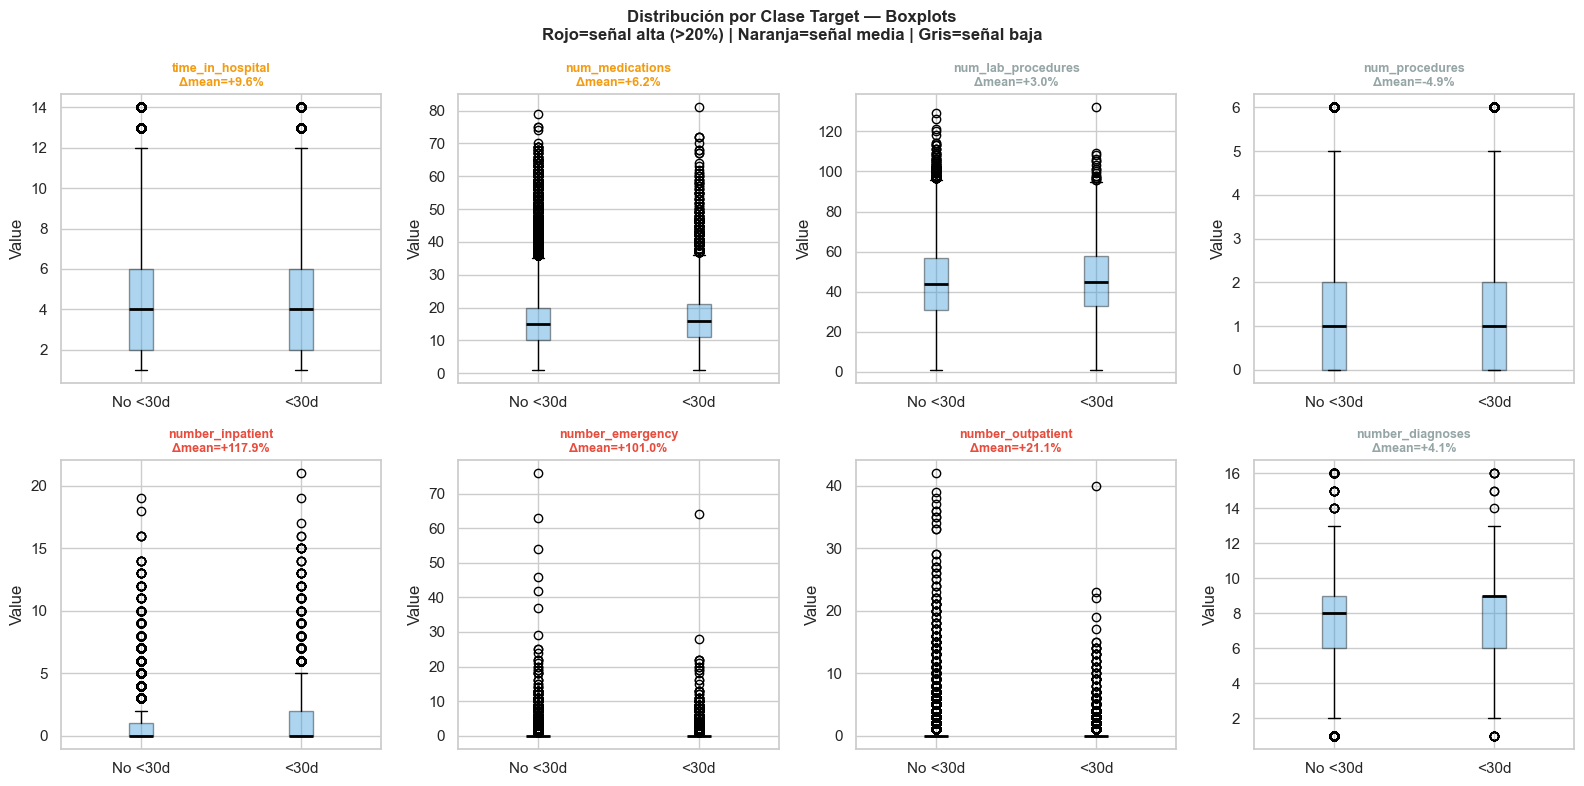

In [15]:
# === VISUALIZACIÓN DE SEÑAL POR CLASE ===
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, var in enumerate(numeric_vars):
    data0 = df[df['readmitted_binary']==0][var]
    data1 = df[df['readmitted_binary']==1][var]
    
    mean0, mean1 = data0.mean(), data1.mean()
    diff = (mean1 - mean0) / mean0 * 100 if mean0 > 0 else 0
    color = '#e74c3c' if abs(diff) > 20 else '#f39c12' if abs(diff) > 5 else '#95a5a6'
    
    axes[i].boxplot([data0, data1], labels=['No <30d', '<30d'],
                    patch_artist=True,
                    boxprops=dict(facecolor='#3498db', alpha=0.4),
                    medianprops=dict(color='black', linewidth=2))
    
    # Colorear el box de clase 1 según señal
    axes[i].set_title(f'{var}\nΔmean={diff:+.1f}%', fontweight='bold', 
                      fontsize=9, color=color)
    axes[i].set_ylabel('Value')

plt.suptitle('Distribución por Clase Target — Boxplots\n'
             'Rojo=señal alta (>20%) | Naranja=señal media | Gris=señal baja', 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/boxplots_by_class.png', dpi=150)
plt.show()

##  Hallazgo 4 — Señal en Variables Numéricas

**Variables con señal alta (Δmean >20%):**
- `number_inpatient` +117.9% — la más importante del grupo
- `number_emergency` +101.0% — segunda en señal
- `number_outpatient` +21.1% — señal moderada

**Interpretación clínica:** La utilización previa del sistema hospitalario
es el predictor más discriminante. Pacientes que ya fueron internados o
tuvieron emergencias previas tienen el doble de probabilidad de readmisión
temprana. Esto justifica la feature `total_visitas_previas` planificada.

**Variables con señal baja:** `num_lab_procedures`, `num_procedures`,
`number_diagnoses` — distribuciones casi idénticas entre clases.
Pueden aportar señal marginal en combinación pero no como predictores solos.

**Nota sobre outliers:** Valores extremos visibles en `number_emergency` (>60)
y `number_inpatient` (>15) — candidatos a análisis de casos extremos en SQL.
Son pacientes de alta utilización que merecen análisis propio.

In [16]:
# === ENCUENTROS MÚLTIPLES POR PACIENTE ===
encounters_per_patient = df.groupby('patient_nbr')['encounter_id'].count()

print("=== DISTRIBUCIÓN DE ENCUENTROS POR PACIENTE ===\n")
print(encounters_per_patient.value_counts().sort_index().head(10))
print(f"\nTotal pacientes únicos:     {encounters_per_patient.shape[0]:,}")
print(f"Total encuentros:           {len(df):,}")
print(f"Pacientes con >1 encuentro: {(encounters_per_patient > 1).sum():,} "
      f"({(encounters_per_patient > 1).mean()*100:.1f}%)")
print(f"Max encuentros un paciente: {encounters_per_patient.max()}")
print(f"\nRatio encuentros/paciente:  {len(df)/encounters_per_patient.shape[0]:.2f}")

=== DISTRIBUCIÓN DE ENCUENTROS POR PACIENTE ===

encounter_id
1     54745
2     10434
3      3328
4      1421
5       717
6       346
7       207
8       111
9        70
10       42
Name: count, dtype: int64

Total pacientes únicos:     71,518
Total encuentros:           101,766
Pacientes con >1 encuentro: 16,773 (23.5%)
Max encuentros un paciente: 40

Ratio encuentros/paciente:  1.42


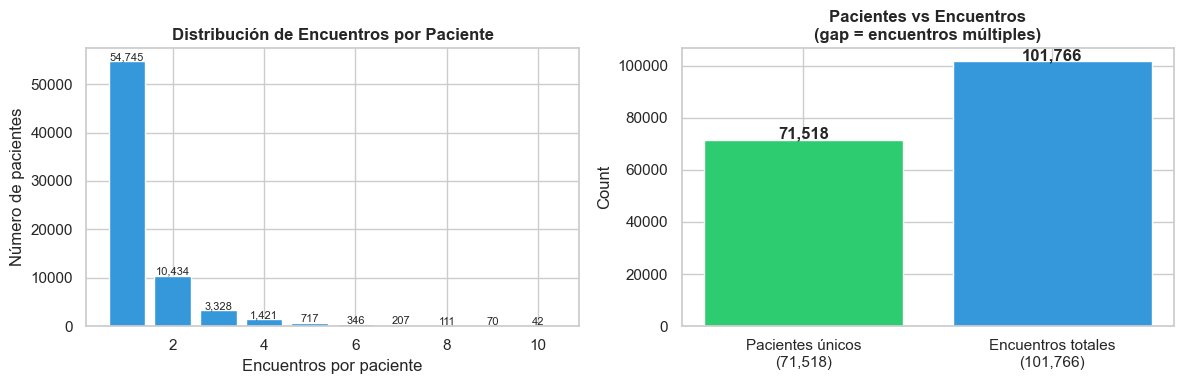

In [17]:
# Visualización de la distribución
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1 — distribución de encuentros por paciente (top 10)
enc_dist = encounters_per_patient.value_counts().sort_index().head(10)
axes[0].bar(enc_dist.index, enc_dist.values, color='#3498db', edgecolor='white')
axes[0].set_xlabel('Encuentros por paciente')
axes[0].set_ylabel('Número de pacientes')
axes[0].set_title('Distribución de Encuentros por Paciente', fontweight='bold')
for x, y in zip(enc_dist.index, enc_dist.values):
    axes[0].text(x, y + 200, f'{y:,}', ha='center', fontsize=8)

# Plot 2 — pacientes únicos vs encuentros totales
labels = ['Pacientes únicos\n(71,518)', 'Encuentros totales\n(101,766)']
values = [71518, 101766]
colors = ['#2ecc71', '#3498db']
axes[1].bar(labels, values, color=colors, edgecolor='white')
axes[1].set_title('Pacientes vs Encuentros\n(gap = encuentros múltiples)', fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(values):
    axes[1].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/processed/encounters_per_patient.png', dpi=150)
plt.show()

## Hallazgo 5 — Encuentros Múltiples por Paciente

**Estructura del dataset:**
- 71,518 pacientes únicos → 101,766 encuentros totales
- 23.5% de pacientes tienen más de un encuentro
- Máximo: 40 encuentros para un solo paciente

**Implicación metodológica crítica — Leakage en el split:**
Si se hace train/test split aleatorio, el mismo paciente puede aparecer
en ambos sets. El modelo aprendería patrones del paciente específico
(no generalizables) y las métricas de test estarían infladas artificialmente.

**Decisión de diseño:**
Usar `GroupShuffleSplit(groups=patient_nbr)` para el split train/test.
Ningún paciente aparece en ambos sets simultáneamente.
Se conservan todos los encuentros elegibles — no se descarta el primer
encuentro por paciente, porque cada alta hospitalaria es una observación
válida de predicción.

**Para el split final:**
```python
from sklearn.model_selection import GroupShuffleSplit
gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=df['patient_nbr']))
```

In [18]:
# === DISCHARGE DISPOSITION — variable crítica doble función ===
# Necesitamos el mapeo de IDs a etiquetas
# Los códigos están en IDs_mapping.csv

mapping_path = Path('../data/raw/IDs_mapping.csv')
mapping_df = pd.read_csv(mapping_path)
print(mapping_df.head(20))
print(f"\nColumnas: {mapping_df.columns.tolist()}")

           admission_type_id  \
0                          1   
1                          2   
2                          3   
3                          4   
4                          5   
5                          6   
6                          7   
7                          8   
8                        NaN   
9   discharge_disposition_id   
10                         1   
11                         2   
12                         3   
13                         4   
14                         5   
15                         6   
16                         7   
17                         8   
18                         9   
19                        10   

                                          description  
0                                           Emergency  
1                                              Urgent  
2                                            Elective  
3                                             Newborn  
4                                       Not Ava

In [19]:
# === PARSEO MANUAL DEL MAPPING FILE ===
# El archivo tiene múltiples tablas apiladas — hay que separarlas

import re

# Leer raw sin header
raw_mapping = pd.read_csv(mapping_path, header=None, names=['id', 'description'])

# Identificar separadores de tabla (filas donde 'id' es texto, no número)
# Las tablas son: admission_type_id, discharge_disposition_id, admission_source_id

discharge_map = {}
capture = False

for _, row in raw_mapping.iterrows():
    if str(row['id']).strip() == 'discharge_disposition_id':
        capture = True
        continue
    if capture:
        try:
            key = int(row['id'])
            discharge_map[key] = str(row['description']).strip()
        except:
            if str(row['id']).strip() in ['admission_type_id', 'admission_source_id']:
                break  # llegamos a la siguiente tabla

print("=== DISCHARGE DISPOSITION MAPPING ===")
for k, v in sorted(discharge_map.items()):
    print(f"  {k:2}: {v}")

=== DISCHARGE DISPOSITION MAPPING ===
   1: Discharged to home
   2: Discharged/transferred to another short term hospital
   3: Discharged/transferred to SNF
   4: Discharged/transferred to ICF
   5: Discharged/transferred to another type of inpatient care institution
   6: Discharged/transferred to home with home health service
   7: Left AMA
   8: Discharged/transferred to home under care of Home IV provider
   9: Admitted as an inpatient to this hospital
  10: Neonate discharged to another hospital for neonatal aftercare
  11: Expired
  12: Still patient or expected to return for outpatient services
  13: Hospice / home
  14: Hospice / medical facility
  15: Discharged/transferred within this institution to Medicare approved swing bed
  16: Discharged/transferred/referred another institution for outpatient services
  17: Discharged/transferred/referred to this institution for outpatient services
  18: nan
  19: Expired at home. Medicaid only, hospice.
  20: Expired in a medical fac

In [20]:
# === EXCLUSIONES — fallecidos y hospicio ===
exclude_disposition = [11, 13, 14, 19, 20, 21]

n_before = len(df)
mask_exclude = df['discharge_disposition_id'].isin(exclude_disposition)

print("=== REGISTROS A EXCLUIR ===")
excl_counts = df[mask_exclude]['discharge_disposition_id'].value_counts()
for idx, count in excl_counts.items():
    print(f"  ID {idx:2} ({discharge_map[idx][:45]}): {count:,}")

print(f"\nTotal a excluir: {mask_exclude.sum():,} ({mask_exclude.sum()/n_before*100:.1f}%)")
print(f"Dataset después de exclusión: {n_before - mask_exclude.sum():,} encuentros")

=== REGISTROS A EXCLUIR ===
  ID 11 (Expired): 1,642
  ID 13 (Hospice / home): 399
  ID 14 (Hospice / medical facility): 372
  ID 19 (Expired at home. Medicaid only, hospice.): 8
  ID 20 (Expired in a medical facility. Medicaid only,): 2

Total a excluir: 2,423 (2.4%)
Dataset después de exclusión: 99,343 encuentros


In [21]:
# Aplicar exclusión
df_clean = df[~mask_exclude].copy()
df_clean = df_clean.reset_index(drop=True)

print(f"Dataset original:  {n_before:,} encuentros")
print(f"Excluidos:         {mask_exclude.sum():,} (fallecidos + hospicio)")
print(f"Dataset limpio:    {len(df_clean):,} encuentros")
print(f"Target balance:    {df_clean['readmitted_binary'].mean()*100:.1f}% clase positiva")

Dataset original:  101,766 encuentros
Excluidos:         2,423 (fallecidos + hospicio)
Dataset limpio:    99,343 encuentros
Target balance:    11.4% clase positiva


##  Hallazgo 6 — Exclusiones Clínicas

**Registros excluidos: 2,423 (2.4%)**
- Fallecidos durante internación (IDs 11, 19, 20, 21): 1,652
- Alta a hospicio (IDs 13, 14): 771

**Justificación:** Estos pacientes no son candidatos a readmisión hospitalaria
por definición. Incluirlos introduciría ruido estructural — el modelo intentaría
aprender patrones de readmisión en registros donde la readmisión es imposible.

**Dataset elegible final: 99,343 encuentros**
A partir de este punto todos los análisis se hacen sobre `df_clean`.

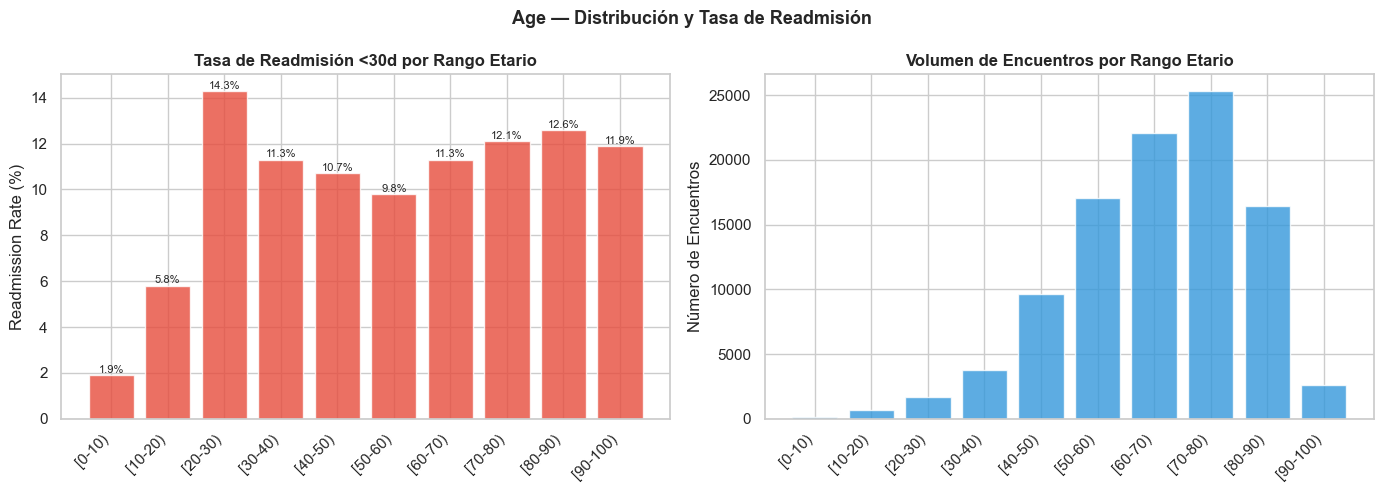

          count  readmission_rate_%
age                                
[0-10)      160               1.900
[10-20)     690               5.800
[20-30)    1649              14.300
[30-40)    3764              11.300
[40-50)    9607              10.700
[50-60)   17060               9.800
[60-70)   22059              11.300
[70-80)   25331              12.100
[80-90)   16434              12.600
[90-100)   2589              11.900


In [22]:
# === AGE vs TARGET ===
age_order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)', 
             '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']

age_stats = df_clean.groupby('age')['readmitted_binary'].agg(['mean', 'count'])
age_stats = age_stats.reindex(age_order)
age_stats['readmission_rate_%'] = (age_stats['mean'] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tasa de readmisión por edad
axes[0].bar(range(len(age_order)), age_stats['readmission_rate_%'], 
            color='#e74c3c', alpha=0.8, edgecolor='white')
axes[0].set_xticks(range(len(age_order)))
axes[0].set_xticklabels(age_order, rotation=45, ha='right')
axes[0].set_ylabel('Readmission Rate (%)')
axes[0].set_title('Tasa de Readmisión <30d por Rango Etario', fontweight='bold')
for i, val in enumerate(age_stats['readmission_rate_%']):
    axes[0].text(i, val + 0.1, f'{val}%', ha='center', fontsize=8)

# Volumen de encuentros por edad
axes[1].bar(range(len(age_order)), age_stats['count'], 
            color='#3498db', alpha=0.8, edgecolor='white')
axes[1].set_xticks(range(len(age_order)))
axes[1].set_xticklabels(age_order, rotation=45, ha='right')
axes[1].set_ylabel('Número de Encuentros')
axes[1].set_title('Volumen de Encuentros por Rango Etario', fontweight='bold')

plt.suptitle('Age — Distribución y Tasa de Readmisión', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/age_analysis.png', dpi=150)
plt.show()

print(age_stats[['count', 'readmission_rate_%']])

##  Hallazgo 7 — Age vs Readmisión

**Patrón no lineal — dos grupos de riesgo:**
- [20-30): tasa más alta del dataset (14.3%) — volumen bajo (1,649 encuentros)
- [70-80) y [80-90): tasas altas (12.1%, 12.6%) — volumen alto (25k+ encuentros)
- [50-60): tasa mínima (9.8%) — el grupo de menor riesgo relativo

**Interpretación clínica:**
Pacientes jóvenes (20-30) con diabetes hospitalizada probablemente representan
casos más severos o de peor control metabólico — selección por severidad.
El riesgo en adultos mayores refleja comorbilidades y fragilidad sistémica.

**Implicación para features:**
Age NO es un predictor lineal — convertirlo a punto medio numérico captura
tendencia general pero pierde la señal del grupo [20-30).
Considerar conservar como categórica ordinal o agregar flag `edad_joven_diabetico`.

**Volumen:** La gran mayoría de encuentros está en [60-90) — 
el modelo va a estar principalmente entrenado en adultos mayores.

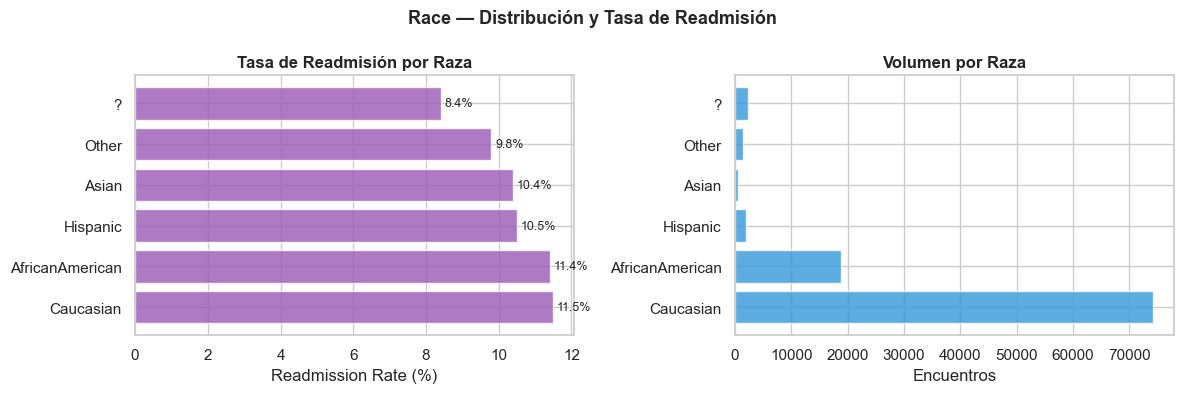

                 count  readmission_rate_%
race                                      
Caucasian        74220              11.500
AfricanAmerican  18772              11.400
Hispanic          2017              10.500
Asian              628              10.400
Other             1472               9.800
?                 2234               8.400


In [23]:
# === RACE vs TARGET ===
race_stats = df_clean.groupby('race')['readmitted_binary'].agg(['mean', 'count'])
race_stats['readmission_rate_%'] = (race_stats['mean'] * 100).round(1)
race_stats = race_stats.sort_values('readmission_rate_%', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].barh(race_stats.index, race_stats['readmission_rate_%'],
             color='#9b59b6', alpha=0.8, edgecolor='white')
axes[0].set_xlabel('Readmission Rate (%)')
axes[0].set_title('Tasa de Readmisión por Raza', fontweight='bold')
for i, val in enumerate(race_stats['readmission_rate_%']):
    axes[0].text(val + 0.1, i, f'{val}%', va='center', fontsize=9)

axes[1].barh(race_stats.index, race_stats['count'],
             color='#3498db', alpha=0.8, edgecolor='white')
axes[1].set_xlabel('Encuentros')
axes[1].set_title('Volumen por Raza', fontweight='bold')

plt.suptitle('Race — Distribución y Tasa de Readmisión', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/race_analysis.png', dpi=150)
plt.show()

print(race_stats[['count', 'readmission_rate_%']])

##  Hallazgo 8 — Race vs Readmisión

**Tasas de readmisión muy similares entre grupos (8.4% — 11.5%):**
- Caucasian: 11.5% (n=74,220 — 75% del dataset)
- AfricanAmerican: 11.4% (n=18,772)
- Hispanic: 10.5% (n=2,017)
- Asian: 10.4% (n=628)
- '?': 8.4% (n=2,234)

**Implicaciones metodológicas:**
1. Race tiene señal predictiva baja como variable individual — diferencia
   máxima de 3pp entre grupos con volúmenes muy distintos.
2. El dataset está fuertemente desbalanceado por raza — 75% Caucasian.
   El modelo va a estar principalmente entrenado en ese grupo.
3. '?' tiene la tasa más baja — el missingness puede ser informativo
   (2.2% de los registros). Se trata como categoría 'Unknown', no se imputa.

**Advertencia para el README:**
Race NO debe interpretarse causalmente. Las diferencias observadas
reflejan acceso al sistema, prácticas de registro y composición
de los 130 hospitales — no diferencias biológicas.

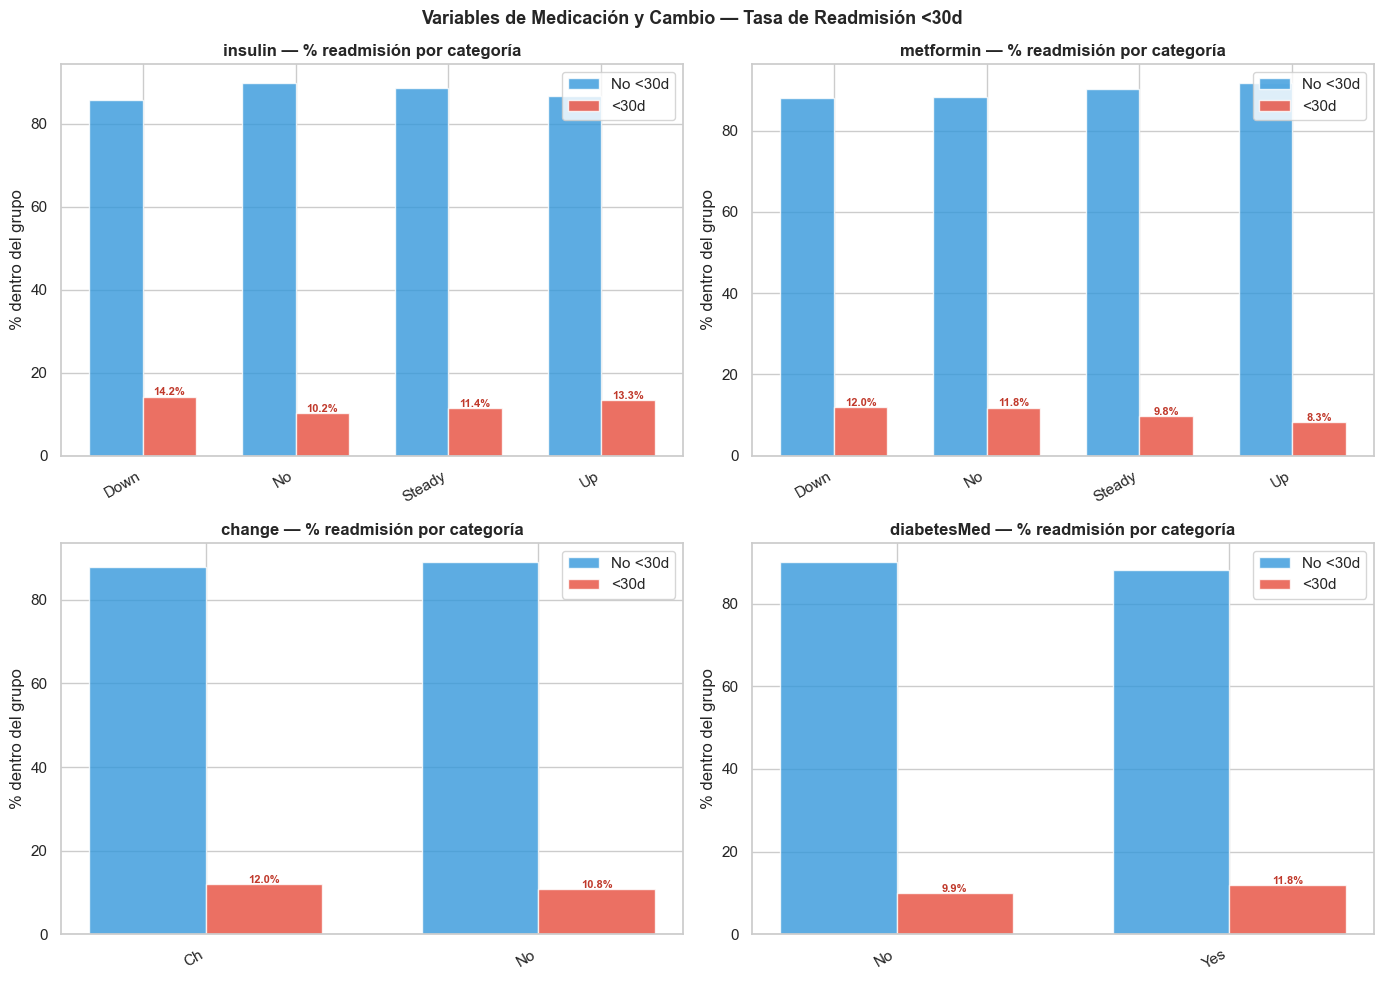

In [24]:
# === MEDICACIÓN vs TARGET — insulina y metformina ===
med_vars = ['insulin', 'metformin', 'change', 'diabetesMed']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, var in enumerate(med_vars):
    ct = pd.crosstab(df_clean[var], df_clean['readmitted_binary'], normalize='index') * 100
    ct.columns = ['No <30d', '<30d']
    
    x = range(len(ct))
    width = 0.35
    axes[i].bar([xi - width/2 for xi in x], ct['No <30d'], 
                width, label='No <30d', color='#3498db', alpha=0.8)
    axes[i].bar([xi + width/2 for xi in x], ct['<30d'], 
                width, label='<30d', color='#e74c3c', alpha=0.8)
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(ct.index, rotation=30, ha='right')
    axes[i].set_ylabel('% dentro del grupo')
    axes[i].set_title(f'{var} — % readmisión por categoría', fontweight='bold')
    axes[i].legend()
    
    # Agregar tasa de readmisión encima de cada barra roja
    for xi, val in zip(x, ct['<30d']):
        axes[i].text(xi + width/2, val + 0.3, f'{val:.1f}%', 
                    ha='center', fontsize=8, color='#c0392b', fontweight='bold')

plt.suptitle('Variables de Medicación y Cambio — Tasa de Readmisión <30d', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/medication_analysis.png', dpi=150)
plt.show()

##  Hallazgo 9 — Medicación vs Readmisión

**Insulina — señal modesta pero presente:**
- Down: 14.2% — mayor tasa (reducción de dosis al alta, posible descontrol)
- Up: 13.3%
- Steady: 11.4%
- No: 10.2% — menor tasa
Patrón clínicamente coherente: cambios en insulina (Up o Down) 
asociados a mayor readmisión que dosis estable.

**Metformina — señal inversa débil:**
- Down: 12.0% → Up: 8.3%
- Aumento de metformina asociado a menor readmisión — posible mejor control.
- Diferencia pequeña (4pp) — señal marginal.

**change y diabetesMed — señal muy baja:**
- change (Ch vs No): 12.0% vs 10.8% — diferencia de 1.2pp
- diabetesMed (Yes vs No): 11.8% vs 9.9% — diferencia de 1.9pp

**Conclusión para feature engineering:**
Insulina justifica conservación individual — tiene el mayor rango de variación.
Metformina justifica conservación individual por plausibilidad clínica,
aunque señal más débil que insulina.
El resto de medicaciones se agrega en `n_medicamentos_cambiados`.

**Nota sobre race:**
Race en este dataset es autorreporte administrativo, no clasificación
biológica ni genética. Las diferencias observadas reflejan composición
hospitalaria y prácticas de registro — no deben interpretarse causalmente.

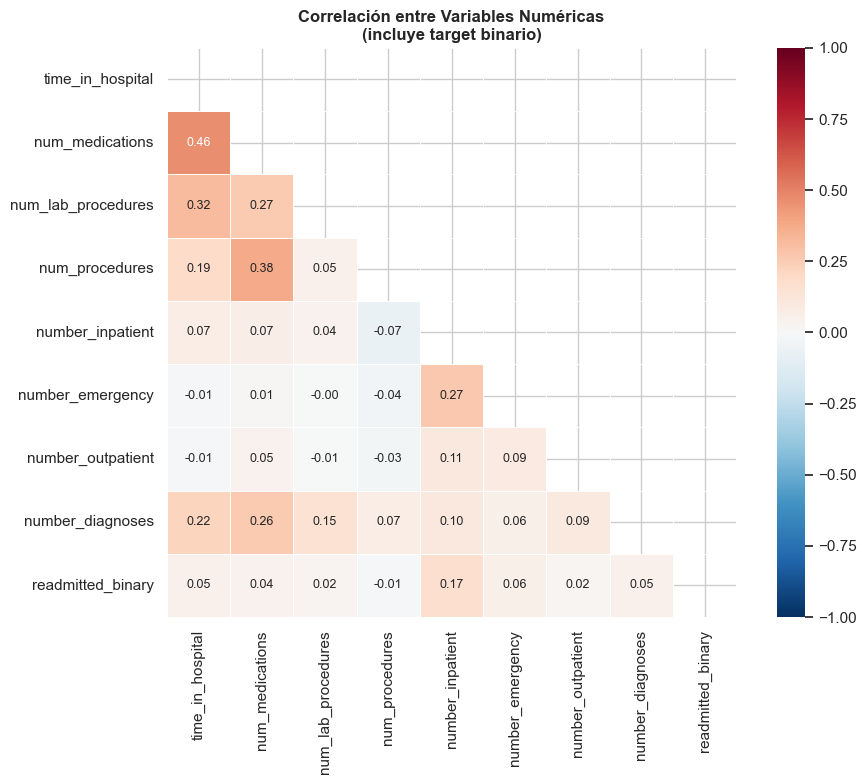

In [25]:
# === HEATMAP DE CORRELACIÓN NUMÉRICA ===
numeric_cols = numeric_vars + ['readmitted_binary']

corr_matrix = df_clean[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 9})

ax.set_title('Correlación entre Variables Numéricas\n(incluye target binario)', 
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('../data/processed/correlation_heatmap.png', dpi=150)
plt.show()

##  Hallazgo 10 — Correlaciones Numéricas

**Multicolinealidad moderada — no problemática para XGBoost:**
- `time_in_hospital` ↔ `num_medications` (0.46): más días = más fármacos administrados
- `num_medications` ↔ `num_procedures` (0.38): proxy compartido de severidad clínica

**Correlaciones con target — bajas individualmente (max 0.17):**
- `number_inpatient` es la variable con mayor correlación lineal con readmisión (0.17)
- Las correlaciones bajas NO implican que las variables sean inútiles —
  XGBoost captura interacciones no lineales que la correlación de Pearson no detecta.
  El Δmean de +117.9% en number_inpatient es señal real, solo que no lineal.

**Variables de utilización previa (inpatient, emergency, outpatient)
tienen correlaciones bajas entre sí con el target pero moderadas entre ellas (0.27) —
justifica agregar `total_visitas_previas` como feature sintético.**

In [26]:
# === CLASIFICACIÓN FARMACOLÓGICA DE LAS 24 VARIABLES DE MEDICACIÓN ===

drug_classes = {
    'Biguanidas': ['metformin'],
    'Sulfonilureas': ['glipizide', 'glyburide', 'glimepiride', 
                      'chlorpropamide', 'tolbutamide', 'tolazamide', 'acetohexamide'],
    'Meglitinidas': ['repaglinide', 'nateglinide'],
    'Tiazolidinedionas': ['pioglitazone', 'rosiglitazone', 'troglitazone'],
    'Inhibidores_alfa_glucosidasa': ['acarbose', 'miglitol'],
    'Combinaciones': ['glyburide-metformin', 'glipizide-metformin',
                      'glimepiride-pioglitazone', 'metformin-rosiglitazone',
                      'metformin-pioglitazone'],
    'Insulina': ['insulin'],
    'Sin_uso_clinico': ['examide', 'citoglipton']  # nunca prescritos en la práctica
}

# Verificar que cubrimos las 24 variables
med_cols = [col for col in df_clean.columns if col in 
            [d for drugs in drug_classes.values() for d in drugs]]
print(f"Variables de medicación mapeadas: {len(med_cols)}/24\n")

for clase, drugs in drug_classes.items():
    print(f"\n{'='*50}")
    print(f"CLASE: {clase}")
    for drug in drugs:
        if drug in df_clean.columns:
            val_counts = df_clean[drug].value_counts()
            pct_no = (val_counts.get('No', 0) / len(df_clean) * 100)
            pct_active = 100 - pct_no
            readm_by_val = df_clean.groupby(drug)['readmitted_binary'].mean() * 100
            print(f"  {drug:<30} activo={pct_active:.1f}%  ", end="")
            for val in ['Down', 'Steady', 'Up']:
                if val in readm_by_val:
                    print(f"{val}:{readm_by_val[val]:.1f}%  ", end="")
            print()

Variables de medicación mapeadas: 23/24


CLASE: Biguanidas
  metformin                      activo=20.0%  Down:12.0%  Steady:9.8%  Up:8.3%  

CLASE: Sulfonilureas
  glipizide                      activo=12.6%  Down:15.5%  Steady:11.2%  Up:13.0%  
  glyburide                      activo=10.6%  Down:9.3%  Steady:10.8%  Up:10.6%  
  glimepiride                    activo=5.2%  Down:13.1%  Steady:10.2%  Up:11.5%  
  chlorpropamide                 activo=0.1%  Down:0.0%  Steady:6.4%  Up:0.0%  
  tolbutamide                    activo=0.0%  Steady:4.8%  
  tolazamide                     activo=0.0%  Steady:7.9%  Up:0.0%  
  acetohexamide                  activo=0.0%  Steady:0.0%  

CLASE: Meglitinidas
  repaglinide                    activo=1.5%  Down:7.0%  Steady:13.3%  Up:18.7%  
  nateglinide                    activo=0.7%  Down:9.1%  Steady:11.9%  Up:4.2%  

CLASE: Tiazolidinedionas
  pioglitazone                   activo=7.3%  Down:15.4%  Steady:10.5%  Up:12.6%  
  rosiglitazone         

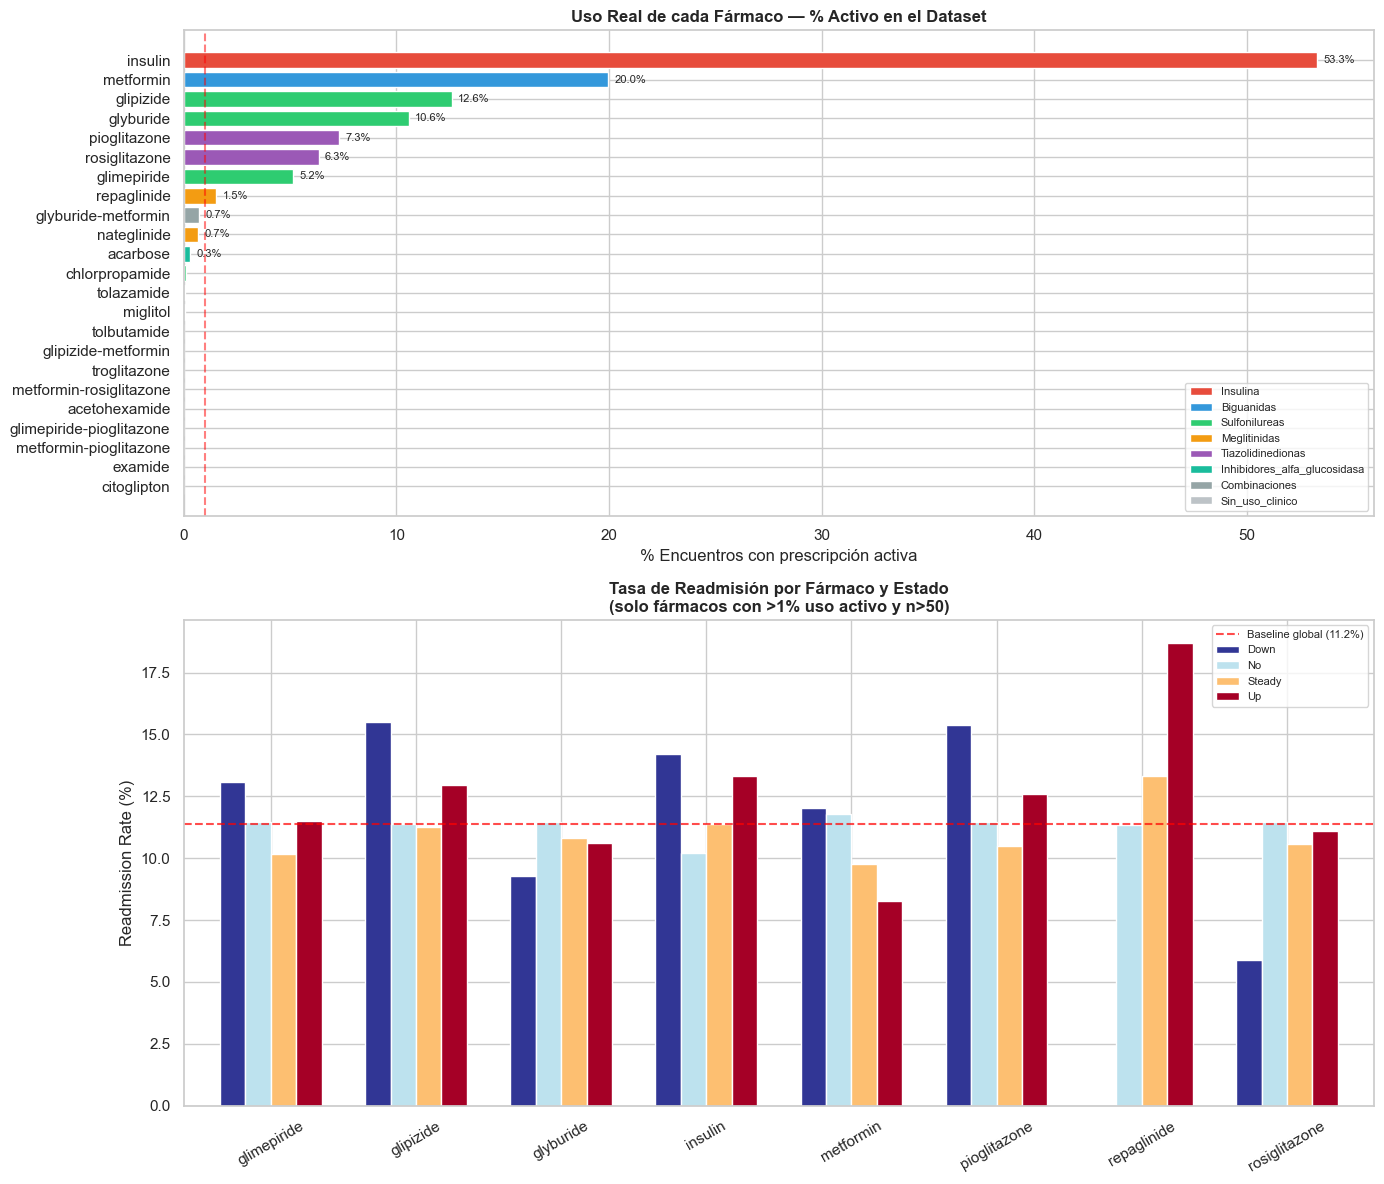

In [27]:
# === VISUALIZACIÓN FARMACOLÓGICA ===
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Plot 1 — % activo por clase farmacológica
drug_activity = {}
for clase, drugs in drug_classes.items():
    for drug in drugs:
        if drug in df_clean.columns:
            pct = (df_clean[drug] != 'No').mean() * 100
            drug_activity[drug] = {'clase': clase, 'pct_activo': pct}

activity_df = pd.DataFrame(drug_activity).T.sort_values('pct_activo', ascending=True)
activity_df['pct_activo'] = activity_df['pct_activo'].astype(float)

color_map = {
    'Insulina': '#e74c3c',
    'Biguanidas': '#3498db', 
    'Sulfonilureas': '#2ecc71',
    'Meglitinidas': '#f39c12',
    'Tiazolidinedionas': '#9b59b6',
    'Inhibidores_alfa_glucosidasa': '#1abc9c',
    'Combinaciones': '#95a5a6',
    'Sin_uso_clinico': '#bdc3c7'
}

colors = [color_map[c] for c in activity_df['clase']]
bars = axes[0].barh(activity_df.index, activity_df['pct_activo'], 
                     color=colors, edgecolor='white')
axes[0].axvline(x=1, color='red', linestyle='--', alpha=0.5, label='1% threshold')
axes[0].set_xlabel('% Encuentros con prescripción activa')
axes[0].set_title('Uso Real de cada Fármaco — % Activo en el Dataset', fontweight='bold')
for bar, val in zip(bars, activity_df['pct_activo']):
    if val > 0.1:
        axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                    f'{val:.1f}%', va='center', fontsize=8)

# Leyenda de clases
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in color_map.items()]
axes[0].legend(handles=legend_elements, loc='lower right', fontsize=8)

# Plot 2 — tasa de readmisión por clase (solo fármacos con >1% activo)
active_drugs = ['insulin', 'metformin', 'glipizide', 'glyburide', 
                'glimepiride', 'pioglitazone', 'rosiglitazone', 'repaglinide']

readm_data = []
for drug in active_drugs:
    for val in ['No', 'Steady', 'Up', 'Down']:
        mask = df_clean[drug] == val
        if mask.sum() > 50:
            rate = df_clean[mask]['readmitted_binary'].mean() * 100
            readm_data.append({'drug': drug, 'status': val, 
                               'readm_rate': rate, 'n': mask.sum()})

readm_plot = pd.DataFrame(readm_data)
pivot = readm_plot.pivot(index='drug', columns='status', values='readm_rate')

pivot.plot(kind='bar', ax=axes[1], colormap='RdYlBu_r', 
           edgecolor='white', width=0.7)
axes[1].set_title('Tasa de Readmisión por Fármaco y Estado\n(solo fármacos con >1% uso activo y n>50)', 
                   fontweight='bold')
axes[1].set_ylabel('Readmission Rate (%)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)
axes[1].axhline(y=df_clean['readmitted_binary'].mean()*100, 
                color='red', linestyle='--', alpha=0.7, label='Baseline global (11.2%)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('../data/processed/pharmacological_analysis.png', dpi=150)
plt.show()

##  Hallazgo 11 — Análisis Farmacológico (mirada de dominio)

### Uso real por clase farmacológica
**Insulina domina con 53.3% de uso** — coherente con el contexto hospitalario.
La diabetes descompensada que requiere internación frecuentemente necesita
insulinización transitoria independientemente del tratamiento ambulatorio previo.

**Metformina: solo 20% activo** — llamativamente bajo para el fármaco de
primera línea en DM2. Explicación clínica: metformina se suspende
rutinariamente durante internación por riesgo de acidosis láctica,
especialmente ante uso de contraste yodado, cirugía o deterioro renal agudo.
Su baja presencia NO refleja que sea poco usada ambulatoriamente —
refleja la práctica hospitalaria de suspensión preventiva.

### Fármacos con cero varianza — eliminación justificada por farmacología
- `examide` y `citoglipton`: 0% activo — nunca llegaron a uso clínico real
- `troglitazone`: retirado del mercado en 2000 por hepatotoxicidad severa (FDA)
  Aparece en el dataset (1999-2008) pero con uso prácticamente nulo
- `acetohexamide`, `tolbutamide`, `chlorpropamide`: sulfonilureas de 1ª generación
  obsoletas, reemplazadas por glipizide/glyburide/glimepiride (2ª generación)

Estas variables se eliminan por criterio farmacológico, no estadístico.
La diferencia es importante: un modelo podría eliminarlas por baja varianza,
pero la razón correcta es que no reflejan práctica clínica vigente.

### Patrones de readmisión con interpretación mecanística

**Insulina Down (14.2%) > Up (13.3%) > Steady (11.4%):**
Reducción de insulina al alta puede reflejar sobredosificación previa
o resolución de la causa aguda — ambos escenarios implican inestabilidad
metabólica reciente, consistente con mayor riesgo de readmisión.

**Metformina Up (8.3%) — tasa más baja:**
Aumento de metformina al alta sugiere optimización del tratamiento
ambulatorio en un paciente estable — perfil de menor riesgo.

**Pioglitazone Down (15.4%) — tasa más alta de las tiazolidinedionas:**
Reducción de pioglitazona puede reflejar retención de líquidos o
insuficiencia cardíaca (efecto adverso conocido de la clase) —
condición que per se aumenta riesgo de readmisión.

**Repaglinide Up (18.7%) — señal extrema pero n pequeño:**
Meglitinidas tienen acción rápida postprandial. Aumento al alta
en n=~15 pacientes — no interpretable estadísticamente.

### Decisión para feature engineering
Variables a conservar individualmente: `insulin`, `metformin`
Variables a agregar en `n_medicamentos_cambiados`: resto con >1% uso
Variables a eliminar directamente: `examide`, `citoglipton`, `troglitazone`,
`acetohexamide`, `tolbutamide`, `chlorpropamide`, `tolazamide`

In [28]:
# === ANÁLISIS DE SESGO POR ACCESO ECONÓMICO ===
# Proxies disponibles: payer_code, race, age, discharge_disposition

# 1. Payer code — quién paga la internación
print("=== PAYER CODE — distribución ===")
print(df_clean['payer_code'].value_counts().head(15))

=== PAYER CODE — distribución ===
payer_code
?     39398
MC    31333
HM     6195
SP     4941
BC     4601
MD     3473
CP     2466
UN     2411
CM     1880
OG     1011
PO      585
DM      545
CH      142
WC      135
OT       92
Name: count, dtype: int64


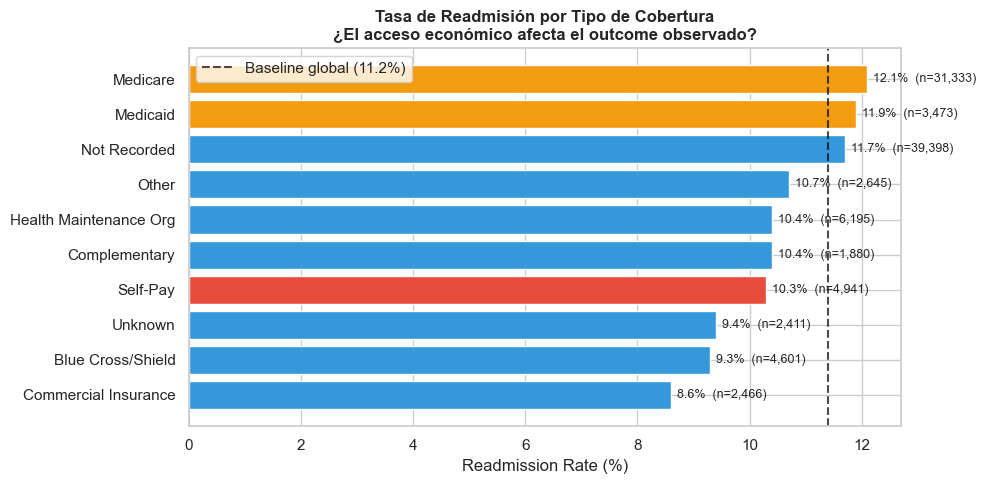

                        count  readmission_rate_%
payer_label                                      
Commercial Insurance     2466               8.600
Blue Cross/Shield        4601               9.300
Unknown                  2411               9.400
Self-Pay                 4941              10.300
Complementary            1880              10.400
Health Maintenance Org   6195              10.400
Other                    2645              10.700
Not Recorded            39398              11.700
Medicaid                 3473              11.900
Medicare                31333              12.100


In [29]:
# Mapeo de códigos relevantes
payer_map = {
    'MC': 'Medicare',
    'MD': 'Medicaid', 
    'SP': 'Self-Pay',
    'HM': 'Health Maintenance Org',
    'BC': 'Blue Cross/Shield',
    'CP': 'Commercial Insurance',
    'UN': 'Unknown',
    'CM': 'Complementary',
    '?':  'Not Recorded'
}

df_clean['payer_label'] = df_clean['payer_code'].map(payer_map).fillna('Other')

# Tasa de readmisión por tipo de pagador
payer_stats = df_clean.groupby('payer_label')['readmitted_binary'].agg(['mean','count'])
payer_stats['readmission_rate_%'] = (payer_stats['mean'] * 100).round(1)
payer_stats = payer_stats[payer_stats['count'] > 200].sort_values('readmission_rate_%')

fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#e74c3c' if label == 'Self-Pay' 
          else '#f39c12' if label in ['Medicaid', 'Medicare']
          else '#3498db' 
          for label in payer_stats.index]

bars = ax.barh(payer_stats.index, payer_stats['readmission_rate_%'],
               color=colors, edgecolor='white')

ax.axvline(x=df_clean['readmitted_binary'].mean()*100, 
           color='black', linestyle='--', alpha=0.7, label='Baseline global (11.2%)')

for bar, (val, n) in zip(bars, zip(payer_stats['readmission_rate_%'], 
                                    payer_stats['count'])):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val}%  (n={n:,})', va='center', fontsize=9)

ax.set_xlabel('Readmission Rate (%)')
ax.set_title('Tasa de Readmisión por Tipo de Cobertura\n'
             '¿El acceso económico afecta el outcome observado?', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/payer_readmission_bias.png', dpi=150)
plt.show()

print(payer_stats[['count', 'readmission_rate_%']])

## 🔍 Hallazgo 12 — Sesgo de Acceso Económico (análisis crítico)

**Hipótesis:** Pacientes sin seguro (Self-Pay) podrían mostrar tasas de
readmisión artificialmente bajas porque no pueden costear una segunda
internación — el outcome "no readmitido" estaría contaminado con
"no pudo volver".

**Resultado observado:**
- Medicare:    12.1% (adultos mayores, cobertura pública)
- Medicaid:    11.9% (bajo ingreso, cobertura pública)  
- Self-Pay:    10.3% (sin seguro — 4,941 pacientes)
- Commercial:   8.6% (seguro privado empleador)

**Interpretación — dos lecturas no excluyentes:**

1. El gradiente existe pero es modesto (12.1% → 10.3% = 1.8pp).
   Podría reflejar parcialmente la barrera económica, pero también
   diferencias en perfil demográfico y severidad clínica entre grupos.

2. Paradójicamente, Commercial Insurance tiene la tasa MÁS BAJA (8.6%).
   Esto sugiere que el gradiente refleja perfil de salud subyacente
   (pacientes con seguro privado tienden a ser más jóvenes y sanos)
   más que solo acceso económico.

**Limitación metodológica para el README:**
Este dataset no permite distinguir entre "no readmitido porque se recuperó"
y "no readmitido porque no pudo volver". El outcome observado es
readmisión al mismo sistema hospitalario — un paciente que busca atención
en otro centro, en urgencias de bajo costo, o que simplemente no busca
atención, cuenta como "no readmitido" en todos los casos.

Esta limitación es estructural e irresoluble con los datos disponibles.
El modelo predice readmisión observable, no necesidad clínica real de atención.

**Nota histórica:** El dataset es de 1999-2008, previo al Affordable Care Act
(2010). La proporción de uninsured en EE.UU. era ~15% en ese período.
Los 4,941 Self-Pay representan ~5% del dataset — probablemente subestimado
por subregistro hospitalario de pacientes sin cobertura.

## Perspectivas No Implementadas — Scope y Limitaciones Epistemológicas

### Por qué NO se hace inferencia causal

Este proyecto predice asociación histórica, no efecto causal de intervenciones.

Para responder "¿qué pasa con el riesgo de readmisión si cambio la dosis de insulina?"
se necesitaría un DAG verificable con supuestos de identificabilidad:
- ausencia de confundidores no observados (severidad real del paciente, adherencia)
- datos de asignación de tratamiento no sesgados (aquí el médico asigna insulina
  a los pacientes MÁS enfermos — causalidad inversa directa)
- idealmente un diseño experimental o cuasi-experimental (RCT, diferencias en diferencias)

Con datos observacionales retrospectivos como este dataset, el do-calculus
requiere supuestos no verificables. Un modelo que "recomiende bajar insulina
para reducir readmisión" podría estar capturando que los pacientes más graves
reciben más insulina — no que la insulina cause readmisión.

**Lo que sí hace este proyecto:** identificar patrones asociativos que pueden
generar hipótesis para estudios prospectivos. SHAP muestra qué variables
están asociadas con readmisión en este dataset histórico — no qué variables
son intervenibles para reducirla.

### Equidad algorítmica — pendiente para Etapa 05 (Dashboard)

El modelo puede tener performance desigual entre grupos demográficos.
Dado el desbalance racial del dataset (75% Caucasian) y las barreras
de acceso documentadas en el Hallazgo 12, existe riesgo real de que
el modelo funcione peor en grupos subrepresentados.

**Análisis planificado para el dashboard:**
- Métricas separadas por grupo racial: ROC-AUC, Recall, Precision
- Métricas separadas por rango etario
- Documentación explícita de grupos con n insuficiente para evaluación confiable

Un modelo preciso a nivel global puede ser inequitativo a nivel de subgrupo.

In [30]:
readme_draft = """
# Clinical Tabular ML — Hospital Readmission Prediction at 30 Days

> Predicting early readmission risk in diabetic patients using clinical 
> and administrative data. Focus on methodological decisions, not metric maximization.

**Dataset:** Diabetes 130-US Hospitals (UCI) | 99,343 encounters | 50 variables  
**Stack:** Python · XGBoost · SHAP · DuckDB · Streamlit

---

## ⚠️ Critical Limitations (read before interpreting results)

### This model predicts association, not causation
Variables with high SHAP values are not necessarily actionable interventions.
The dataset is observational and retrospective — causal identification requires
assumptions (no unmeasured confounders, no reverse causality) that cannot be
verified here. A variable like `number_inpatient` predicting readmission does not
mean reducing hospitalizations will reduce readmission risk.

For causal inference, a DAG with testable identification assumptions,
or a prospective/quasi-experimental design, would be required.

### The outcome "not readmitted" is ambiguous
A patient classified as "not readmitted" may have:
- Recovered successfully (true negative)
- Sought care at a different facility (not captured)
- Been unable to afford a return visit (access barrier)

Self-Pay patients showed 10.3% readmission vs 12.1% for Medicare.
This gap likely reflects both health profile differences AND economic barriers
to care access. The model predicts observable readmission to this hospital
system — not true clinical need for readmission.

Dataset covers 1999-2008, prior to the Affordable Care Act (2010).
Uninsured rates were ~15% nationally in this period.

### Algorithmic fairness — known risk, partially evaluated
The dataset is 75% Caucasian. Model performance on minority groups
(Hispanic n=2,017, Asian n=628) may be unreliable due to small sample sizes.

Dashboard includes subgroup performance metrics by race and age range.
Groups with n < 500 should not be used for deployment decisions.

### Temporal and geographic scope
Data from 130 US hospitals, 1999-2008. Clinical protocols, medication
availability, and discharge practices have changed significantly.
Generalization to other health systems (LATAM, Europe) requires
external validation.

---

## Methodological Decisions

### Why GroupShuffleSplit and not random split
23.5% of patients have multiple encounters (max: 40).
Random split would leak patient-specific patterns into the test set,
inflating performance metrics artificially.
Solution: GroupShuffleSplit(groups=patient_nbr) ensures no patient
appears in both train and test sets.

### Why not impute A1Cresult and max_glu_serum
94.7% and 83.3% missing respectively. The absence of these measurements
is clinically informative — it reflects that the test was not ordered,
which itself may correlate with severity or care quality.
Strategy: binary flags `was_A1C_measured` and `was_glucose_measured`.

### Why threshold tuning matters
Default threshold 0.5 is not optimal with severe class imbalance.
The clinical cost of a false negative (missing a readmission) exceeds
the cost of a false positive (unnecessary alert).
Threshold selected by maximizing F2-score on the PR curve,
explicitly weighting recall over precision.

### Why SMOTE is not the primary strategy
SMOTE generates synthetic patients by interpolating between real records.
In clinical tabular data, synthetic patients can combine features that
don't clinically co-occur. Preferred strategy: class_weight / scale_pos_weight.
SMOTE evaluated as secondary experiment with honest reporting.

---

## Pharmacological Notes (domain knowledge)
Variables eliminated by pharmacological criterion, not statistical:
- `examide`, `citoglipton`: never reached clinical use
- `troglitazone`: withdrawn from market in 2000 (hepatotoxicity)
- `acetohexamide`, `tolbutamide`, `chlorpropamide`, `tolazamide`: 
   obsolete 1st-generation sulfonylureas

`metformin` low use (20%) reflects standard hospital practice of
suspension during admission (lactic acidosis risk with contrast/surgery),
not low ambulatory prevalence.

---

## Results
[TO BE COMPLETED AFTER MODELING]

---

*This is a methodological portfolio project. No clinical deployment is proposed 
or implied. Predictions are not validated in a prospective clinical context.*
"""

# Guardar borrador
with open('../README_draft.md', 'w', encoding='utf-8') as f:
    f.write(readme_draft)

print("✅ README_draft.md guardado en raíz del proyecto")
print("   → Completar sección Results después del modelado")
print("   → Traducir y pulir para el README final el Día 5")

✅ README_draft.md guardado en raíz del proyecto
   → Completar sección Results después del modelado
   → Traducir y pulir para el README final el Día 5


In [31]:
# === GUARDAR ARTEFACTOS FINALES ===
from pathlib import Path

# 1. Dataset limpio
df_clean.to_parquet(Path('../data/processed/clean_data.parquet'), index=False)
# 2. Resumen
print("✅ clean_data.parquet guardado")
print(f"\n{'='*50}")
print("RESUMEN FINAL DEL EDA")
print(f"{'='*50}")
print(f"Encuentros originales:         101,766")
print(f"Excluidos (fallec/hospicio):     2,423")
print(f"Dataset elegible final:         {len(df_clean):,}")
print(f"Pacientes únicos:               {df_clean['patient_nbr'].nunique():,}")
print(f"Clase positiva (<30d):          {df_clean['readmitted_binary'].mean()*100:.1f}%")
print(f"scale_pos_weight XGBoost:       {(df_clean['readmitted_binary']==0).sum()/(df_clean['readmitted_binary']==1).sum():.2f}")
print(f"\n✅ EDA completo — 12 hallazgos documentados")
print(f"✅ README_draft.md guardado")
print(f"✅ Listo para Día 2: limpieza + SQL analítico")

✅ clean_data.parquet guardado

RESUMEN FINAL DEL EDA
Encuentros originales:         101,766
Excluidos (fallec/hospicio):     2,423
Dataset elegible final:         99,343
Pacientes únicos:               69,990
Clase positiva (<30d):          11.4%
scale_pos_weight XGBoost:       7.78

✅ EDA completo — 12 hallazgos documentados
✅ README_draft.md guardado
✅ Listo para Día 2: limpieza + SQL analítico
